In [26]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



## Полная таблица признаков

| № | Название | Полное название | Единицы | Категория | Статус |
|---|----------|----------------|---------|-----------|--------|
| 1 | `Date Time` | Дата и время | - | Временной | Удален |
| 2 | `p (mbar)` | Атмосферное давление | миллибар | Метеорологический | Оставлен |
| 3 | `T (degC)` | Температура воздуха | градусы Цельсия | Метеорологический | Оставлен |
| 4 | `Tpot (K)` | Потенциальная температура | Кельвины | Производный | Удален |
| 5 | `Tdew (degC)` | Точка росы | градусы Цельсия | Производный | Удален |
| 6 | `rh (%)` | Относительная влажность | проценты | Метеорологический | **Целевая переменная** |
| 7 | `VPmax (mbar)` | Макс. давление насыщенного пара | миллибар | Производный | Удален |
| 8 | `VPact (mbar)` | Фактическое давление пара | миллибар | Производный | Удален |
| 9 | `VPdef (mbar)` | Дефицит давления пара | миллибар | Производный | Удален |
| 10 | `sh (g/kg)` | Удельная влажность | г/кг | Производный | Удален |
| 11 | `H2OC (mmol/mol)` | Молярная концентрация H2O | ммоль/моль | Производный | Удален |
| 12 | `rho (g/m**3)` | Плотность воздуха | г/м³ | Производный | Удален |
| 13 | `wv (m/s)` | Скорость ветра | м/с | Метеорологический | Оставлен |
| 14 | `max. wv (m/s)` | Максимальная скорость ветра | м/с | Производный | Удален |
| 15 | `wd (deg)` | Направление ветра | градусы | Метеорологический | Удален |
| 16 | `rain (mm)` | Количество осадков | мм | Метеорологический | Оставлен |
| 17 | `raining (s)` | Длительность дождя | секунды | Производный | Удален | 
| 18 | `SWDR (W/m²)` | Коротковолновая радиация | Вт/м² | Радиационный | Оставлен | 
| 19 | `PAR (μmol/m²/s)` | Фотосинтетическая радиация | мкмоль/м²/с | Радиационный | Удален | 
| 20 | `max. PAR` | Максимальная PAR | мкмоль/м²/с | Производный | Удален | 
| 21 | `Tlog (degC)` | Логарифмическая температура | °C | Производный | Удален | 
| 22 | `CO2 (ppm)` | Концентрация CO₂ | ppm | Химический | Оставлен | 

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12

df = pd.read_csv(
    '/kaggle/input/datasets/lkssaa862/mpi-roof-2025-1/mpi_roof_2025 (1).csv', 
    parse_dates=['Date Time'], 
    index_col='Date Time',
    dayfirst=True
)
#print(df['rho (g/m**3)'].head(100))
print(df.head())
print(f"с {df.index.min()} по {df.index.max()}")
print(df.shape)

if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index, dayfirst=True)
df.sort_index(inplace=True)

cols_to_drop = ['Tpot (K)', 'Tdew (degC)', 'VPmax (mbar)', 'VPact (mbar)', 
                'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 
                'max. wv (m/s)', 'raining (s)', 'max. PAR (�mol/m�/s)', 
                'Tlog (degC)', 'PAR (�mol/m�/s)', 'wd (deg)']

#cols_to_drop_existing = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f"{df.isnull().sum().sum()} пропусков") 
df.fillna(method='ffill', inplace=True)
print(f"{df.isnull().sum().sum()} пропусков") 


                     p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
Date Time                                                                
2025-01-01 00:10:00    997.30     -1.56    271.80        -2.97    90.0   
2025-01-01 00:20:00    997.05     -0.90    272.48        -2.66    87.8   
2025-01-01 00:30:00    996.96     -0.51    272.88        -2.44    86.7   
2025-01-01 00:40:00    996.77     -0.27    273.14        -2.26    86.3   
2025-01-01 00:50:00    996.62     -0.09    273.33        -2.14    86.0   

                     VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  \
Date Time                                                                  
2025-01-01 00:10:00          5.45          4.90          0.54       3.06   
2025-01-01 00:20:00          5.72          5.02          0.70       3.14   
2025-01-01 00:30:00          5.89          5.10          0.78       3.19   
2025-01-01 00:40:00          5.99          5.17          0.82       3.23   
2025-01-01 00:50:00      

In [28]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df['rh (%)'], autolag='AIC')

print(f"ADF статистика: {adf_result[0]}")
print(f"p: {adf_result[1]}")
print(f"ряд стационарен")

ADF статистика: -19.09987752600339
p: 0.0
ряд стационарен


In [29]:
rh = df['rh (%)']
lags_to_test = [1, 2, 3, 6, 12, 24, 48, 144]
print("\nЗначения автокорреляции (ACF):")
print(f"{'Лаг':>6} | {'Время':>12} | {'ACF':>8} | {'итог':>20}")

for lag in lags_to_test:
    n = len(rh)
    rh_mean = rh.mean()
    acf_num = np.sum((rh[lag:] - rh_mean) * (rh[:-lag] - rh_mean))
    acf_den = np.sum((rh - rh_mean)**2)
    acf = acf_num / acf_den
     
    if abs(acf) >= 0.7:
        strength = "Очень сильная"
    elif abs(acf) >= 0.5:
        strength = "Сильная"
    elif abs(acf) >= 0.3:
        strength = "Умеренная"
    elif abs(acf) >= 0.1:
        strength = "Слабая"
    else:
        strength = "Очень слабая"
    
    time_min = lag * 10
    if time_min < 60:
        time_str = f"{time_min} мин"
    else:
        time_str = f"{time_min//60} ч {time_min%60} мин"
    
    print(f"{lag:6d} | {time_str:>12} | {acf:8.4f} | {strength:>20}")



Значения автокорреляции (ACF):
   Лаг |        Время |      ACF |                 итог
     1 |       10 мин |   1.0000 |        Очень сильная
     2 |       20 мин |   1.0000 |        Очень сильная
     3 |       30 мин |   1.0000 |        Очень сильная
     6 |    1 ч 0 мин |   1.0000 |        Очень сильная
    12 |    2 ч 0 мин |   0.9999 |        Очень сильная
    24 |    4 ч 0 мин |   0.9998 |        Очень сильная
    48 |    8 ч 0 мин |   0.9994 |        Очень сильная
   144 |   24 ч 0 мин |   0.9966 |        Очень сильная


In [30]:
Q1 = rh.quantile(0.25)
Q3 = rh.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
if upper_bound>100: upper_bound = 100

outliers_low = rh[rh < lower_bound]
outliers_high = rh[rh > upper_bound]
total_outliers = len(outliers_low) + len(outliers_high)

print(f"Q1 (25-й перцентиль): {Q1:.2f}%")
print(f"Q3 (75-й перцентиль): {Q3:.2f}%")
print(f"IQR = Q3 - Q1: {IQR:.2f}%")
print(f"Нижняя граница: {lower_bound:.2f}%")
print(f"Верхняя граница: {upper_bound:.2f}%")

print(f"Выбросов снизу: {len(outliers_low)} ({len(outliers_low)/len(rh)*100:.2f}%)")
print(f"Выбросов сверху: {len(outliers_high)} ({len(outliers_high)/len(rh)*100:.2f}%)")
print(f"Всего выбросов: {total_outliers} ({total_outliers/len(rh)*100:.2f}%)")


Q1 (25-й перцентиль): 63.99%
Q3 (75-й перцентиль): 93.70%
IQR = Q3 - Q1: 29.71%
Нижняя граница: 19.42%
Верхняя граница: 100.00%
Выбросов снизу: 2 (0.00%)
Выбросов сверху: 0 (0.00%)
Всего выбросов: 2 (0.00%)


среднее: 77.4%
медиана: 81.6%
минимум: 19.2%
максимум: 100.0%
стандартное отклонение: 19.1%
корреляции:
CO2 (ppm)      : 0.560
rain (mm)      : 0.075
p (mbar)       : 0.040
wv (m/s)       : -0.348
SWDR (W/m�)    : -0.585
T (degC)       : -0.623


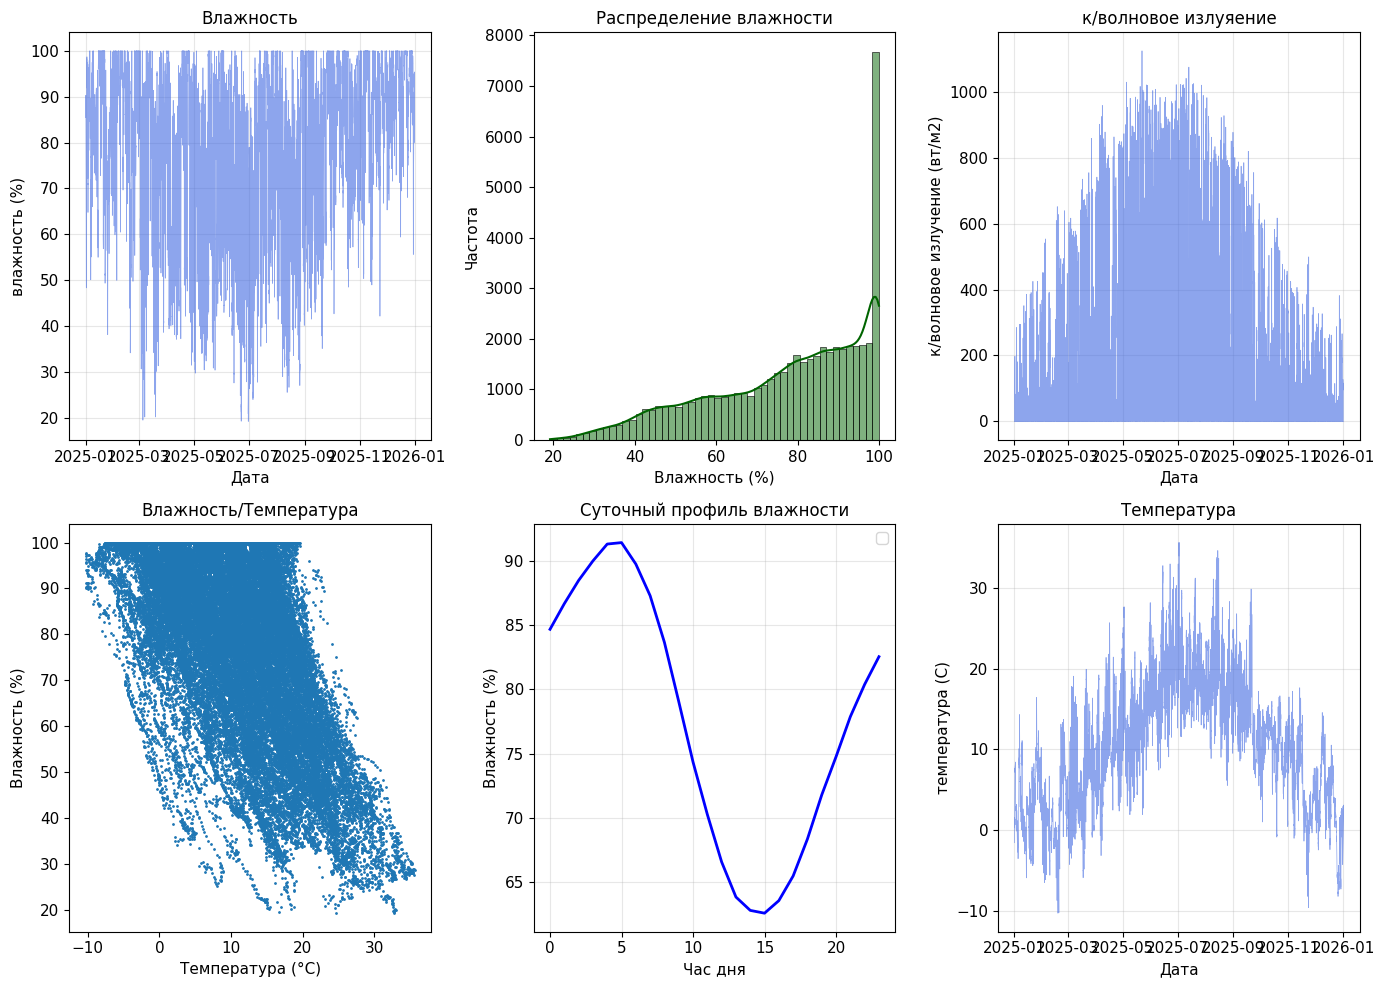

In [31]:

print(f"среднее: {df['rh (%)'].mean():.1f}%")
print(f"медиана: {df['rh (%)'].median():.1f}%")
print(f"минимум: {df['rh (%)'].min():.1f}%")
print(f"максимум: {df['rh (%)'].max():.1f}%")
print(f"стандартное отклонение: {df['rh (%)'].std():.1f}%")


print(f"корреляции:")
correlations = df.corr()['rh (%)'].sort_values(ascending=False)
for var, corr in correlations.items():
    if var != 'rh (%)':
        print(f"{var:15s}: {corr:.3f}")

fig, axes = plt.subplots(2, 3, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.plot(df.index, df['rh (%)'], color='royalblue', alpha=0.6, linewidth=0.5)
ax1.set_title('Влажность', fontsize=12)
ax1.set_ylabel('влажность (%)')
ax1.set_xlabel('Дата')
ax1.grid(True, alpha=0.3)


ax2 = axes[0, 1]
sns.histplot(df['rh (%)'], bins=50, kde=True, color='darkgreen', ax=ax2)
ax2.set_title('Распределение влажности', fontsize=12)
ax2.set_xlabel('Влажность (%)')
ax2.set_ylabel('Частота')


ax3 = axes[1, 0]
scatter = ax3.scatter(df['T (degC)'], df['rh (%)'], s=1)
ax3.set_title('Влажность/Температура', fontsize=12)
ax3.set_xlabel('Температура (°C)')
ax3.set_ylabel('Влажность (%)')


ax4 = axes[1, 1]
hourly_rh = df.groupby(df.index.hour)['rh (%)'].agg(['mean', 'std'])
ax4.plot(hourly_rh.index, hourly_rh['mean'], 'b-', linewidth=2)

ax4.set_title('Суточный профиль влажности', fontsize=12)
ax4.set_xlabel('Час дня')
ax4.set_ylabel('Влажность (%)')
ax4.legend()
ax4.grid(True, alpha=0.3)

ax5 = axes[1, 2]
ax5.plot(df.index, df['T (degC)'], color='royalblue', alpha=0.6, linewidth=0.5)
ax5.set_title('Температура', fontsize=12)
ax5.set_ylabel('температура (C)')
ax5.set_xlabel('Дата')
ax5.grid(True, alpha=0.3)

ax6 = axes[0, 2]
ax6.plot(df.index, df['SWDR (W/m�)'], color='royalblue', alpha=0.6, linewidth=0.5)
ax6.set_title('к/волновое излуяение', fontsize=12)
ax6.set_ylabel('к/волновое излучение (вт/м2)')
ax6.set_xlabel('Дата')
ax6.grid(True, alpha=0.3)

plt.tight_layout()




In [32]:
for lag in [1, 2, 3, 6, 12]:  
    df[f'rh_lag_{lag}'] = df['rh (%)'].shift(lag)
for lag in [1, 3, 6]:
    df[f'temp_lag_{lag}'] = df['T (degC)'].shift(lag)
for lag in [1, 6]:
    df[f'pressure_lag_{lag}'] = df['p (mbar)'].shift(lag)
    df[f'wind_lag_{lag}'] = df['wv (m/s)'].shift(lag)
for lag in [6, 12]:
   df[f'SWDR (W/m�)_lag_{lag}'] = df['SWDR (W/m�)'].shift(lag)

for window in [6, 12]:
    df[f'rh_rolling_mean_{window}'] = df['rh (%)'].rolling(window=window).mean()
    df[f'rh_rolling_std_{window}'] = df['rh (%)'].rolling(window=window).std()
    df[f'temp_rolling_mean_{window}'] = df['T (degC)'].rolling(window=window).mean()


df['rh_diff_1'] = df['rh (%)'].diff(1)
df['rh_diff_6'] = df['rh (%)'].diff(6)
df['temp_diff_1'] = df['T (degC)'].diff(1)
df['temp_diff_6'] = df['T (degC)'].diff(6)


df['hour'] = df.index.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['day_of_year'] = df.index.dayofyear
df['doy_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)


df['Target_rh_+2h'] = df['rh (%)'].shift(-12)
df['Target_rh_+24h'] = df['rh (%)'].shift(-144)

print(f"{len(df)} строк")

initial_len = len(df)
df.dropna(inplace=True)

print(f"{len(df)} строк")

52560 строк
52404 строк


In [33]:
feature_cols = [col for col in df.columns if col not in ['Target_rh_+2h','Target_rh_+24h','rh (%)']]
X = df[feature_cols]
y = df['Target_rh_+2h']
y1 = df['Target_rh_+24h']
print(f"признаков: {len(feature_cols)}")
print(feature_cols)


split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


print(f"обучение: {X_train.shape[0]} строк (с {df.index[0]} по {df.index[split_idx-1]})")
print(f"тест: {X_test.shape[0]} строк (с {df.index[split_idx]} по {df.index[-1]})")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

признаков: 36
['p (mbar)', 'T (degC)', 'wv (m/s)', 'rain (mm)', 'SWDR (W/m�)', 'CO2 (ppm)', 'rh_lag_1', 'rh_lag_2', 'rh_lag_3', 'rh_lag_6', 'rh_lag_12', 'temp_lag_1', 'temp_lag_3', 'temp_lag_6', 'pressure_lag_1', 'wind_lag_1', 'pressure_lag_6', 'wind_lag_6', 'SWDR (W/m�)_lag_6', 'SWDR (W/m�)_lag_12', 'rh_rolling_mean_6', 'rh_rolling_std_6', 'temp_rolling_mean_6', 'rh_rolling_mean_12', 'rh_rolling_std_12', 'temp_rolling_mean_12', 'rh_diff_1', 'rh_diff_6', 'temp_diff_1', 'temp_diff_6', 'hour', 'hour_sin', 'hour_cos', 'day_of_year', 'doy_sin', 'doy_cos']
обучение: 41923 строк (с 2025-01-01 02:10:00 по 2025-10-19 05:10:00)
тест: 10481 строк (с 2025-10-19 05:20:00 по 2025-12-31 00:00:00)


In [34]:
results = {}

lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

results['Lasso'] = {'MAE': mae_lasso, 'RMSE': rmse_lasso, 'R2': r2_lasso}



rf_model = RandomForestRegressor(n_estimators=100, 
                                 max_depth=15,
                                 min_samples_split=10,
                                 min_samples_leaf=5,
                                 random_state=42, 
                                 n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

results['Random Forest'] = {'MAE': mae_rf, 'RMSE': rmse_rf, 'R2': r2_rf}

results_df = pd.DataFrame({
    'Модель': list(results.keys()),
    'MAE (%)': [results[m]['MAE'] for m in results],
    'RMSE (%)': [results[m]['RMSE'] for m in results],
    'R²': [results[m]['R2'] for m in results]
}).sort_values('MAE (%)')

print(results_df.to_string(index=False))

       Модель  MAE (%)  RMSE (%)       R²
Random Forest 3.410253  4.820144 0.813175
        Lasso 3.914315  5.149798 0.786746


In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



def create_sequences(X, y, seq_length=12):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, seq_length=12)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, seq_length=12)

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(12, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_seq, y_train_seq, epochs=30, batch_size=32, validation_split=0.1, callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=0)
y_pred_lstm = lstm_model.predict(X_test_seq, verbose=0).flatten()
results['LSTM'] = {
    'MAE': mean_absolute_error(y_test_seq, y_pred_lstm),
    'RMSE': np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm)),
    'R2': r2_score(y_test_seq, y_pred_lstm)
}

results_df = pd.DataFrame({
    'Модель': list(results.keys()),
    'MAE (%)': [results[m]['MAE'] for m in results],
    'RMSE (%)': [results[m]['RMSE'] for m in results],
    'R²': [results[m]['R2'] for m in results]
}).sort_values('MAE (%)')

print(results_df.to_string(index=False))


       Модель  MAE (%)  RMSE (%)       R²
Random Forest 3.410253  4.820144 0.813175
        Lasso 3.914315  5.149798 0.786746
         LSTM 5.423319  6.782216 0.630493


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



def create_sequences(X, y, seq_length=12):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, seq_length=12)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, seq_length=12)


gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(12, X_train_seq.shape[2])),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train_seq, y_train_seq, epochs=30, batch_size=32, validation_split=0.1, callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=0)
y_pred_gru = gru_model.predict(X_test_seq, verbose=0).flatten()
results['GRU'] = {
    'MAE': mean_absolute_error(y_test_seq, y_pred_gru),
    'RMSE': np.sqrt(mean_squared_error(y_test_seq, y_pred_gru)),
    'R2': r2_score(y_test_seq, y_pred_gru)
}

results_df = pd.DataFrame({
    'Модель': list(results.keys()),
    'MAE (%)': [results[m]['MAE'] for m in results],
    'RMSE (%)': [results[m]['RMSE'] for m in results],
    'R²': [results[m]['R2'] for m in results]
}).sort_values('MAE (%)')

print(results_df.to_string(index=False))


       Модель  MAE (%)  RMSE (%)       R²
Random Forest 3.410253  4.820144 0.813175
        Lasso 3.914315  5.149798 0.786746
          GRU 5.414148  7.255203 0.577158
         LSTM 5.423319  6.782216 0.630493


In [37]:

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y1.iloc[:split_idx], y1.iloc[split_idx:]


print(f"обучение: {X_train.shape[0]} строк (с {df.index[0]} по {df.index[split_idx-1]})")
print(f"тест: {X_test.shape[0]} строк (с {df.index[split_idx]} по {df.index[-1]})")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
results24h = {}

lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

results24h['Lasso 24h'] = {'MAE': mae_lasso, 'RMSE': rmse_lasso, 'R2': r2_lasso}



rf_model = RandomForestRegressor(n_estimators=100, 
                                 max_depth=15,
                                 min_samples_split=10,
                                 min_samples_leaf=5,
                                 random_state=42, 
                                 n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

results24h['Random Forest 24h'] = {'MAE': mae_rf, 'RMSE': rmse_rf, 'R2': r2_rf}

def create_sequences(X, y, seq_length=12):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, seq_length=12)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, seq_length=12)

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(12, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_seq, y_train_seq, epochs=30, batch_size=32, validation_split=0.1, callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=0)
y_pred_lstm = lstm_model.predict(X_test_seq, verbose=0).flatten()
results24h['LSTM 24h'] = {
    'MAE': mean_absolute_error(y_test_seq, y_pred_lstm),
    'RMSE': np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm)),
    'R2': r2_score(y_test_seq, y_pred_lstm)
}

gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(12, X_train_seq.shape[2])),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train_seq, y_train_seq, epochs=30, batch_size=32, validation_split=0.1, callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=0)
y_pred_gru = gru_model.predict(X_test_seq, verbose=0).flatten()
results24h['GRU 24h'] = {
    'MAE': mean_absolute_error(y_test_seq, y_pred_gru),
    'RMSE': np.sqrt(mean_squared_error(y_test_seq, y_pred_gru)),
    'R2': r2_score(y_test_seq, y_pred_gru)
}

results24h_df = pd.DataFrame({
    'Модель': list(results24h.keys()),
    'MAE (%)': [results24h[m]['MAE'] for m in results24h],
    'RMSE (%)': [results24h[m]['RMSE'] for m in results24h],
    'R²': [results24h[m]['R2'] for m in results24h]
}).sort_values('MAE (%)')

print(results24h_df.to_string(index=False))


обучение: 41923 строк (с 2025-01-01 02:10:00 по 2025-10-19 05:10:00)
тест: 10481 строк (с 2025-10-19 05:20:00 по 2025-12-31 00:00:00)
           Модель   MAE (%)  RMSE (%)        R²
        Lasso 24h  7.803283 10.018156  0.149429
Random Forest 24h  9.830655 11.617389 -0.143805
         LSTM 24h 13.273679 16.517691 -1.311651
          GRU 24h 18.688182 22.370443 -3.240067
